In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.constants import Boltzmann
import warnings
from numba import jit
import os

## IsingModel

In [11]:
class IsingModel:
    
    def __init__(self, M, N, J, H):
        '''
        Initialization.
            lattice is M by N sites
            J: interaction between neighbors (units: kT)
            H: background field (units: kT)
        '''
        self.J = J   # storing paramteres
        self.H = H
        self.M = M   # row
        self.N = N   # coloumn
        lattice_state = np.random.choice([-1, 1], size=(self.M, self.N))  # initialize lattice sites with -1 or 1 with equal prob
        self.lattice_state = lattice_state 
        self.SIR_counter = np.ones([self.M, self.N]) * -1  # initiate an SIR_counter
    
    def update_SIR_counter(self, I_t, R_t, inf_i, inf_j):
        '''
        After each lattice sweeps (analogous to days), the SIR counter has to updated
        
        - I_t:           - infectious time, the time (number of lattice sweeps / days) until the spin stays infectious
        - R_t:           - recovery time, the time until the spin stays immune and in a healthy status
        
        - lattice_state: - the spin states of the Ising lattice, MxN matrix
                         - -1 represents HEALTHY state, +1 represents INFECTED state
                         
        - SIR_counter:   - the tracker for the Susceptible - Infected - Recovered status of the population, MxN matrix
                         - each [i, j] site corresponds to the SIR state of the lattice_state[i, j] spin
                         - values: x =  -1 (SUSCEPTIBLE), the spin is susceptible to catch the disease
                                   x = +1, +2, +3, ..., I_t (INFECTIOUS), the spin is infected since x sweeps (days)
                                   x = -R_t, -(R_t-1), -(R_t-2), ..., -2 (RECOVERED), the spin remains healthy until the next x sweeps
                                   x = 0 (RECOVERED), the spin remains healthy for all sweeps'''
      
        '1) Add +1 to all the values except for susceptible (-1) and immune spins (0)'
        self.SIR_counter[(self.SIR_counter != -1) & (self.SIR_counter != 0)] += 1 

        '2) Keep track of the newly infected spins'
        self.SIR_counter[inf_i, inf_j] = + 1  
        
        '3)  Recover those spins that are infected larger than the infectious time'
        rec_i, rec_j = np.nonzero((self.SIR_counter > I_t))
        self.lattice_state[rec_i, rec_j] = - self.lattice_state[rec_i, rec_j]  # flip the recovered spins
        if R_t > 0:
            self.SIR_counter[self.SIR_counter > I_t] = - R_t                       # indicate the recovery in the SIR_counter
        else:
            self.SIR_counter[self.SIR_counter > I_t] = 0                           # indicate the inifinite immunity in the SIR_counter
            
        
    def ferro_state(self, val):  
        self.lattice_state = np.ones((self.M, self.N)) * val     
        
    def plot_lattice(self, folder_path, n, figsize=(1,1)):
        assert os.path.exists(folder_path), f"The folder '{folder_path}' does not exist."
        plt.figure(figsize=figsize)
        imgplot = plt.imshow(self.lattice_state, cmap='bwr', vmin=-1, vmax=1)
        imgplot.set_interpolation('none')     
        plt.xticks(range(0, self.N, 1), color = 'white')
        plt.yticks(range(0, self.M, 1), color = 'white')
        plt.tick_params(axis='x', which='both', bottom=False, top=False)
        plt.tick_params(axis='y', which='both', left=False, right=False)
        plt.savefig(folder_path + '/lattice_plot_' + str(n) + '.png')
        #plt.show();
        plt.close();
    
    def flip_spin(self, i, j):
        '''
        Flip the sign of spin at site (i, j)
        '''
        self.lattice_state[i, j] = - self.lattice_state[i, j]

    def infected_neighbours(self, i, j):
        spin_here = self.lattice_state[i, j]  # value of spin here
        
        if j == 0:
            spin_left = self.lattice_state[i, self.N - 1] # last column to the right
        else:
            spin_left = self.lattice_state[i, j - 1]
        
        if j == self.N - 1: 
            spin_right = self.lattice_state[i, 0]
        else:
            spin_right = self.lattice_state[i, j + 1]
            
        if i == self.M - 1: 
            spin_below = self.lattice_state[0, j]
        else: 
            spin_below = self.lattice_state[i + 1, j]
        
        if i == 0: 
            spin_above = self.lattice_state[self.M - 1, j]
        else:
            spin_above = self.lattice_state[i - 1, j]
        
        neighbours = np.array([spin_above, spin_below, spin_left, spin_right])
        inf_neighbours = np.count_nonzero(neighbours == 1)
            
        return inf_neighbours

    
    def E_spin(self, i, j):
        '''
        Calculate energy of spin (i, j) with periodic boundary conditions
        '''
        
        spin_here = self.lattice_state[i, j]  # value of spin here
        
        if j == 0:
            spin_left = self.lattice_state[i, self.N - 1] # last column to the right
        else:
            spin_left = self.lattice_state[i, j - 1]
        
        if j == self.N - 1: 
            spin_right = self.lattice_state[i, 0]
        else:
            spin_right = self.lattice_state[i, j + 1]
            
        if i == self.M - 1: 
            spin_below = self.lattice_state[0, j]
        else: 
            spin_below = self.lattice_state[i + 1, j]
        
        if i == 0: 
            spin_above = self.lattice_state[self.M - 1, j]
        else:
            spin_above = self.lattice_state[i - 1, j]
        
        E = (- self.H*spin_here) - self.J*spin_here*(spin_above + spin_below + spin_left + spin_right)
        return E

    def E_lattice(self):
        '''
        Calculate energy of lattice normalized by the number of spins
        '''
        E = 0.0
        for i in range(self.M):
            for j in range(self.N):
                E += self.E_spin(i, j)

        E_normalized = (E - self.H* np.sum(self.lattice_state) ) / (2.0 * self.M * self.N)

        return E_normalized
          
    def M_lattice(self):
        '''
        Calculate net magentization normalized by the number of spins
        '''
        return  1.0 * np.sum(self.lattice_state) / (self.M * self.N)   

## sweep_lattice()

In [30]:
def sweep_lattice(model, kT, I_t, R_t):
    '''
    Perform N*M Monte Carlo spin flip attempts
    - model: Ising lattice model object instance
    - T: temperature
    returns: fraction of Monte Carlo proposals accepted
    '''
    #mapping_dict = {0: 0.05, 1: 0.1, 2: 0.2, 3: 0.4, 4: 0.8 }
    mapping_dict = {0: 0.05, 1: 0.05, 2: 0.05, 3: 0.05, 4: 0.05 }
    sus_i, sus_j = np.nonzero((model.SIR_counter == -1)) # get the indeces of the susceptible spins
    inf_i, inf_j = [], []
    sus_seq = list(range(0, len(sus_i)))  
    np.random.shuffle(sus_seq)  # get a random sequence of the susceptible spin indeces 
    
    for k in sus_seq:
        i = sus_i[k]        # choose the susceptible spin (i,j)
        j = sus_j[k]
        
        inf_neighbours = model.infected_neighbours(i, j)      
        P =  mapping_dict[inf_neighbours] 
        if np.random.uniform(0, 1) < P :   # accept move, infect the spin
            model.flip_spin(i, j)
            inf_i.append(i)
            inf_j.append(j)
            
    return inf_i, inf_j

In [32]:
rand_infected = np.random.choice(range(0,2))
rand_infected

0

## simulate()

In [13]:
def simulate(folder_path, save, M, N, J, H, kT, n_sweeps, n_burn_sweeps, I_t, R_t): 
    '''
    Monte Carlo simulation of Ising model in Canonical ensemble at kT, starting from a ferromagnetic case
    
    - M, N: dimensions of the 2D Ising lattice
    - kT:  temperature
    - J: interaction energy
    - H: magnetisation
    - n_sweeps: total number of Monte Carlo sweeps to perform in the simulation
    - n_burn_sweeps: number of sweeps for equilibration (no samples taken during this period)

    '''
    # --- INITIATIONS -----
    t0 = time.time() 
    k = 0                                              # number of sampling sweep rounds
    fraction_accepted_during_sampling = 0
    NI = []
    S = []
    I = []
    R = []
    M_samples = np.zeros(n_sweeps)
    E_samples = np.zeros(n_sweeps)
    E_samples_eq = np.zeros(int(n_sweeps - n_burn_sweeps))
    M_samples_eq = np.zeros(int(n_sweeps - n_burn_sweeps))
    spin_tracker = np.zeros([n_sweeps, 2])
    
    model = IsingModel(M, N, J, H)                     # initiate the Ising lattice
    model.ferro_state(-1)                              # start from all spin HEALTHY state (s[i,j] = -1) 
    rand_inf_i = np.random.choice(range(0,M))
    rand_inf_j = np.random.choice(range(0,N))
    model.flip_spin(rand_inf_i, rand_inf_j)                    # infect a random spin
    model.update_SIR_counter(I_t, R_t, rand_inf_i, rand_inf_j) # update the SIR counter
    
    # --- MONTE CARLO SAMPLING - FINITE IMMUNITY ---- 
    for n in range(n_sweeps): 
        if save == True:
            model.plot_lattice(folder_path, n, figsize=(1,1))
        NI.append(np.count_nonzero(model.SIR_counter == 1))
        I.append(np.count_nonzero(model.SIR_counter >= 1))
        S.append(np.count_nonzero(model.SIR_counter == -1))
        R.append(np.count_nonzero((model.SIR_counter < -1) | (model.SIR_counter == 0)))
        spin_tracker[n,0] = model.lattice_state[9,9]
        spin_tracker[n,1] = model.SIR_counter[9,9]
        inf_i, inf_j = sweep_lattice(model, kT, I_t, R_t) # 1) sweep the lattice, infect the susceptible spins and update the counter
        model.update_SIR_counter(I_t, R_t, inf_i, inf_j)
        M_samples[n] = model.M_lattice()
        E_samples[n] = model.E_lattice()

        if n >= n_burn_sweeps:    # hopefully the system equilibrated
            #fraction_accepted_during_sampling += fraction_accepted    
            E_samples_eq[k] = model.E_lattice()
            M_samples_eq[k] = model.M_lattice()
            k += 1

    #frac_accepted = 1.0 * fraction_accepted_during_sampling / (n_sweeps - n_burn_sweeps)
 
    return spin_tracker, E_samples, M_samples, E_samples_eq, M_samples_eq, np.array(NI), np.array(S), np.array(I), np.array(R)
    

## plot_sweeps()

In [19]:
def plot_sweeps(s, i, r, M_samples, n_sweeps, folder_path, n_round, kT, I_t, R_t):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,5))
    
    ax1.scatter(range(n_sweeps), s, s=0.3, marker='o',color='blue', label='Susceptible (spin = -1)')
    ax1.scatter(range(n_sweeps), i, s=0.3, marker='o', color='red', label ='Infected (spin = +1)')
    ax1.scatter(range(n_sweeps), r, s=0.1, marker='x', color='green', label='Recovered (spin = -1)')
    ax1.legend(markerscale=5, scatterpoints=1, handletextpad=0.1)
    ax1.set_xlabel('Sweeps')
    ax1.set_ylabel('Number of spins')

    ax2.scatter(range(n_sweeps), M_samples, s=0.3, color='firebrick', label='Magnetisation')
    ax2.legend(markerscale=5, scatterpoints=1, handletextpad=0.1)
    ax2.set_xlabel('Sweeps')
    ax2.set_ylabel('Lattice magnetisation')
    ax2.set_ylim(-1, 1)
    
    if R_t == 0:
        fig.suptitle(f'kT = {round(kT,1)} | Infectious time: {I_t} sweep(s) | Total recovery', weight = 'bold')
    else:
        fig.suptitle(f'kT = {round(kT,1)} | Infectious time: {I_t} sweep(s) | Recovery time: {R_t-1} sweep(s)', weight = 'bold')

    plt.savefig(folder_path + '/' + str(n_round)+ '_SIRM_during_sweeps_' + str(round(kT,1)) + '_kT.png')
    plt.show();
    #plt.close();

def plot_means(folder_path, M_eq_arr, E_eq_arr, S_arr, I_arr, R_arr, NI_arr, kT_list, I_t, R_t):
    
    M_avg = np.mean(np.mean(M_eq_arr, axis=2), axis = 0)
    E_avg = np.mean(np.mean(E_eq_arr, axis=2), axis = 0)
    M_std = np.std(np.mean(M_eq_arr, axis=2), axis = 0)
    E_std = np.std(np.mean(E_eq_arr, axis=2), axis = 0)
    
    S_avg = np.mean(np.mean(S_arr, axis=2), axis = 0)
    I_avg = np.mean(np.mean(I_arr, axis=2), axis = 0)
    R_avg = np.mean(np.mean(R_arr, axis=2), axis = 0)
    NI_avg = np.mean(np.mean(NI_arr, axis=2), axis = 0)
    S_std = np.std(np.mean(S_arr, axis=2), axis = 0)
    I_std = np.std(np.mean(I_arr, axis=2), axis = 0)
    R_std = np.std(np.mean(R_arr, axis=2), axis = 0)
    NI_std = np.std(np.mean(NI_arr, axis=2), axis = 0)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,4))
    ax1.plot(kT_list, M_avg, linewidth=2,  label='Magnetisation', color = 'firebrick')
    ax1.fill_between(kT_list, M_avg - M_std, M_avg + M_std, alpha=0.3, label='Standard Deviation', color = 'firebrick')
    ax1.set_xlabel('kT')
    ax1.set_ylabel('Mean lattice magnetisation')
    ax1.set_ylim(-1, 1)
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(kT_list, E_avg, linewidth=2, label='Energy')
    ax2.fill_between(kT_list, E_avg - E_std, E_avg + E_std, alpha=0.3, label='Standard Deviation')
    ax2.set_xlabel('kT')
    ax2.set_ylabel('Mean lattice energy')
    ax2.legend()
    ax2.grid(True)

    ax3.plot(kT_list, S_avg, color='b', linewidth=2, label='Susceptible')
    ax3.plot(kT_list, I_avg, color='r', linewidth=2, label='Infected')
    ax3.plot(kT_list, R_avg, color='g', linewidth=2, label='Recovered', linestyle=(0, (5, 5)))
    ax3.plot(kT_list, NI_avg, color='black', linewidth=2, label='Newly infected', linestyle='dotted')
    ax3.set_xlabel('kT')
    ax3.set_ylabel('Number of spins')
    ax3.fill_between(kT_list, S_avg - S_std, S_avg + S_std, alpha=0.3, color='b')
    ax3.fill_between(kT_list, I_avg - I_std, I_avg + I_std, alpha=0.3, color ='r')
    ax3.fill_between(kT_list, R_avg - R_std, R_avg + R_std, alpha=0.3, color ='g')
    ax3.fill_between(kT_list, NI_avg - NI_std, NI_avg + NI_std, alpha=0.3, color ='black')
    ax3.legend()
    ax3.grid(True)
    
    if R_t == 0:
        fig.suptitle(f'Infectious time: {I_t} sweep(s) | Total recovery\n ', weight = 'bold')
    else:
        fig.suptitle(f'Infectious time: {I_t} sweep(s) | Recovery time: {R_t-1} sweep(s)\n ', weight = 'bold')
    plt.savefig(folder_path  + '/mean_ME_SIR' + '.png')
    plt.show();

def spin_SIR_plotter(kT_list, kT, n_max, spin_tracker_arr):
    idx = kT_list.index(kT)
    spins = spin_tracker_arr[0, idx, :, 0]
    SIR = spin_tracker_arr[0, idx, :, 1]
    spins = spins[:n_max]
    SIR = SIR[:n_max]
    plt.figure(figsize=(10, 2))
    # Set colors based on spins array
    colors = ['b' if spin == -1 else 'r' for spin in spins]
    
    # Masking to get only one scatter point per data point
    mask = range(len(spins))
    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=10, label='spin = -1'),
                        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10, label='spin = + 1')], loc='upper right')
    plt.scatter(mask, SIR, s=1, color=colors)
    plt.title(f'kT = {kT_list[idx]}')
    plt.xlabel('Iteration')
    plt.ylabel('SIR Value')
    plt.show();

## repeated_sampling()

In [65]:
def repeated_sampling(folder_path, M, N, J, H, I_t, R_t, kT_list, n_repeat, n_sweeps, n_burn_sweeps):
    '''
    Repeats the monte carlo sampling at temperatures kT in kT_list, n_repeat times
    
             5 SWEEP ROUNDS (k)
    array([[[0., 0., 0., 0., 0.], 4 TEMPERATURES (j)
            [0., 0., 0., 0., 0.],     
            [0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.]],
    
           [[0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.],         3 REPETITIONS OF THE SAMPLING (i)
            [0., 0., 0., 0., 0.]],
    
           [[0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.],
            [0., 0., 0., 0., 0.]]])
    '''
    assert os.path.exists(folder_path), f"The folder '{folder_path}' does not exist."
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in scalar divide")
    warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in scalar divide")
    
    # -- INITIATIONS ----
    E_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    M_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    E_eq_arr = np.zeros([n_repeat, len(kT_list), n_burn_sweeps])
    M_eq_arr = np.zeros([n_repeat, len(kT_list), n_burn_sweeps])
    NI_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    S_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    I_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    R_arr = np.zeros([n_repeat, len(kT_list), n_sweeps])
    spin_tracker_arr = np.zeros([n_repeat, len(kT_list), n_sweeps, 2])
    
    
    # --- REPEATED SAMPLING ROUNDS ---
    print(f'Starting simulation with I_t={I_t}, R_t={R_t}', flush = True)
    for i in range(n_repeat):
        print(f'Sampling round {i+1}...\n', flush=True)
        
        # --- SIMULATE THE SWEEPS AT VARIUS kT ---- 
        for j in range(0, len(kT_list)):       
 
            t0 = time.time()
            spin_tracker, E_samples, M_samples, E_samples_eq, M_samples_eq, NI, S, I, R = simulate(M, N, J, H, kT_list[j], n_sweeps, n_burn_sweeps, I_t, R_t)
            E_arr[i,j]    = E_samples
            M_arr[i,j]    = M_samples
            E_eq_arr[i,j] = E_samples_eq
            M_eq_arr[i,j] = M_samples_eq
            S_arr[i,j]    = S
            I_arr[i,j]    = I
            R_arr[i,j]    = R
            NI_arr[i,j]   = NI
            spin_tracker_arr[i, j] = spin_tracker
            print(f'   kT = {round(kT_list[j], 2)}, M_mean = {np.mean(M_samples_eq)}, S_mean = {np.mean(S)}, I_mean = {np.mean(I)}, Sim time: {round(time.time()-t0, 4)} sec')
            plot_sweeps(S, I, R, M_samples, n_sweeps, folder_path, i+1, kT_list[j], I_t, R_t)
            
        print(f'Finished sampling round {i+1}.\n', flush=True)
    print(f'Finished simulation.', flush=True)
    
    plot_means(folder_path, M_eq_arr, E_eq_arr, S_arr, I_arr, R_arr, NI_arr, kT_list, I_t, R_t)
    
    # Saving the data
    '''np.savetxt(folder_path + '/E_arr.csv', E_arr, delimiter=',')
    np.savetxt(folder_path + '/M_arr.csv', M_arr, delimiter=',')
    np.savetxt(folder_path + '/E_eq_arr.csv', E_eq_arr, delimiter=',')
    np.savetxt(folder_path + '/M_eq_arr.csv', M_eq_arr, delimiter=',')
    np.savetxt(folder_path + '/S_arr.csv', S_arr, delimiter=',')
    np.savetxt(folder_path + '/I_arr.csv', I_arr, delimiter=',')
    np.savetxt(folder_path + '/R_arr.csv', R_arr, delimiter=',')
    np.savetxt(folder_path + '/NI_arr.csv', NI_arr, delimiter=',')'''
    
    return spin_tracker_arr, E_arr, M_arr, E_eq_arr, M_eq_arr, NI_arr, S_arr, I_arr, R_arr


# Simulations

### Non-boltzmann weight

In [36]:
M, N, J, H = 20, 20, 1.0, 0.0
I_t, R_t = 10, 1
n_sweeps, n_burn_sweeps = 2000, 1000
kT = 2
folder_path = './I3_R1'
save = False
spin_tracker, E_samples, M_samples, E_samples_eq, M_samples_eq, NI, S, I, R = simulate(folder_path, save, M, N, J, H, kT, n_sweeps, n_burn_sweeps, I_t, R_t)


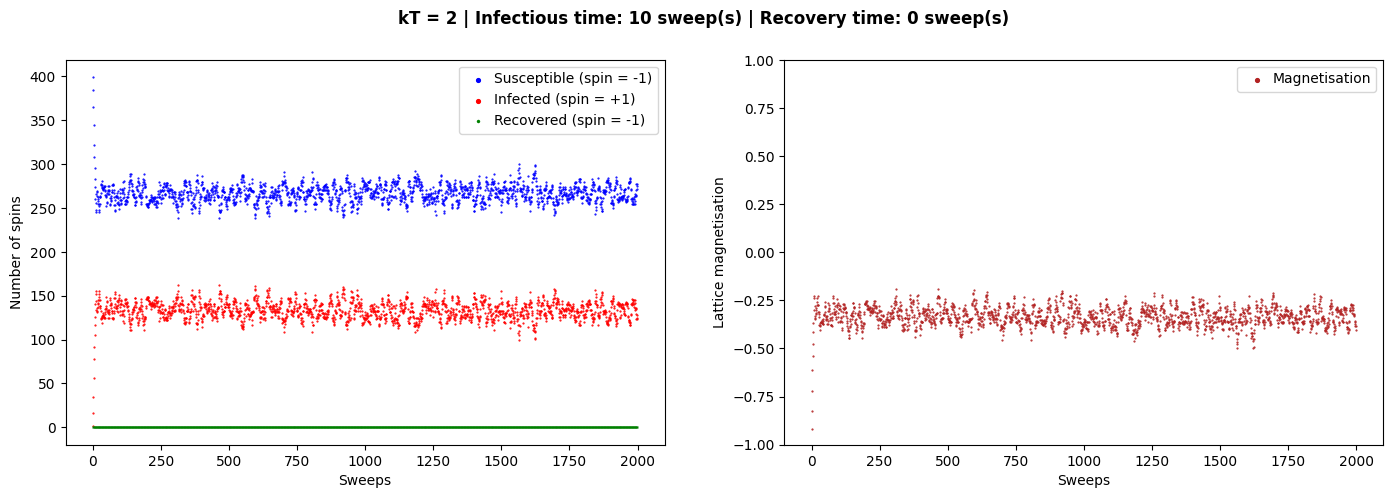

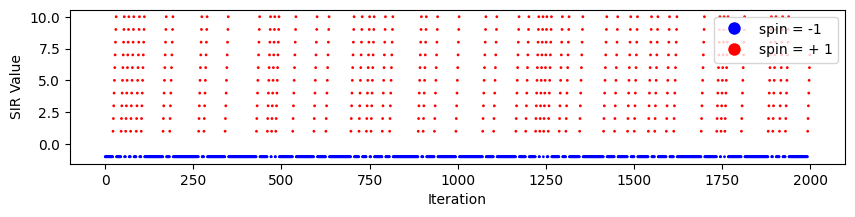

In [37]:
plot_sweeps(S, I, R, M_samples, n_sweeps, folder_path, 1, kT, I_t, R_t)

n_max = 2000
spins = spin_tracker[:, 0]
SIR = spin_tracker[:, 1]
spins = spins[:n_max]
SIR = SIR[:n_max]
plt.figure(figsize=(10, 2))
colors = ['b' if spin == -1 else 'r' for spin in spins]
mask = range(len(spins))
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=10, label='spin = -1'),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10, label='spin = + 1')], loc='upper right')
plt.scatter(mask, SIR, s=1, color=colors)
plt.xlabel('Iteration')
plt.ylabel('SIR Value')
plt.show();

### Simulation 1

Starting simulation with I_t=1, R_t=0
Sampling round 1...

   kT = 0.0, M_mean = -1.0, S_mean = 400.0, I_mean = 0.0, Sim time: 21.5851 sec
   kT = 0.2, M_mean = -1.0, S_mean = 400.0, I_mean = 0.0, Sim time: 16.3781 sec
   kT = 0.4, M_mean = -1.0, S_mean = 400.0, I_mean = 0.0, Sim time: 15.6761 sec
   kT = 0.6, M_mean = -0.999995, S_mean = 398.5135, I_mean = 0.0015, Sim time: 16.7174 sec
   kT = 0.8, M_mean = -0.9999150000000001, S_mean = 382.21, I_mean = 0.0165, Sim time: 17.2928 sec
   kT = 1.0, M_mean = -0.9996600000000001, S_mean = 278.3775, I_mean = 0.1005, Sim time: 13.8409 sec
   kT = 1.2, M_mean = -0.999625, S_mean = 127.99, I_mean = 0.1885, Sim time: 8.4917 sec
   kT = 1.4, M_mean = -0.9999450000000001, S_mean = 46.786, I_mean = 0.2, Sim time: 5.2674 sec
   kT = 1.6, M_mean = -0.999995, S_mean = 22.252, I_mean = 0.2, Sim time: 5.223 sec
   kT = 1.8, M_mean = -1.0, S_mean = 10.179, I_mean = 0.2, Sim time: 3.9967 sec
   kT = 2.0, M_mean = -1.0, S_mean = 4.5045, I_mean = 0.2, Sim 

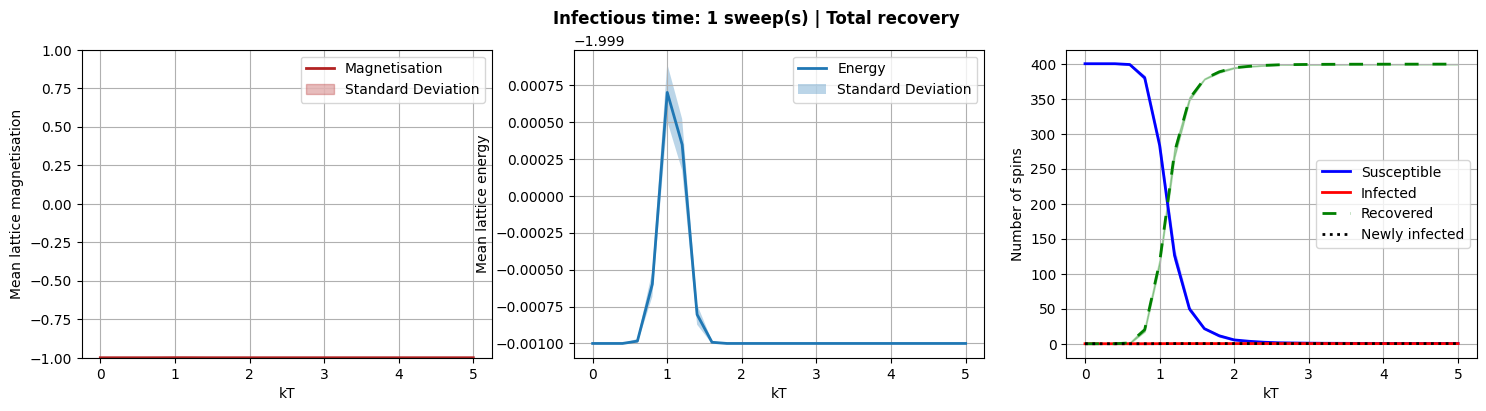

In [69]:
folder_path = './I1_R0'
M, N, J, H = 20, 20, 1.0, 0.0
I_t, R_t = 1, 0
n_sweeps, n_burn_sweeps = 2000, 1000
n_repeat = 5
n_round = 1
kT_list = list(np.arange(0, 5.2, 0.2))

spin_tracker_arr, E_arr, M_arr, E_eq_arr, M_eq_arr, NI_arr, S_arr, I_arr, R_arr = repeated_sampling(folder_path, M, N, J, H, I_t, R_t, kT_list, n_repeat, n_sweeps, n_burn_sweeps)
